# I.IMPORT CÁC THƯ VIỆN


In [1]:

# Cài đặt các thư viện cần thiết
!pip install scikit-learn matplotlib seaborn pandas numpy

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import os


# II. Kết nối drive


In [2]:

from google.colab import drive
drive.mount('/content/drive')




# Thay đổi đường dẫn này theo vị trí dữ liệu của bạn trên Google Drive
TRAIN_DIR = '/content/drive/MyDrive/data_lab_cv1/train'
VAL_DIR = '/content/drive/MyDrive/data_lab_cv1/validation'
TEST_DIR = '/content/drive/MyDrive/data_lab_cv1/test'
CHECKPOINT_DIR = '/content/drive/MyDrive/labAI'
RESULTS_DIR = '/content/drive/MyDrive/labAI'

# Tạo thư mục nếu chưa có
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)


Mounted at /content/drive


# III.CẤU HÌNH HYPERPARAMETERS =====

In [4]:


IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001
SAVE_FREQ = 20  # Lưu mô hình mỗi 20 epochs


#IV. TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU

In [5]:
# ===== BƯỚC 5: TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU =====
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Số lượng classes
num_classes = len(train_generator.class_indices)
print(f"Số lượng classes: {num_classes}")
print(f"Class indices: {train_generator.class_indices}")


NameError: name 'ImageDataGenerator' is not defined

#V. BƯỚC 6: XÂY DỰNG MÔ HÌNH VỚI PRETRAINED MODEL

In [3]:
# ===== BƯỚC 6: XÂY DỰNG MÔ HÌNH VỚI PRETRAINED MODEL =====
# Sử dụng MobileNetV2
base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Đóng băng các layers của base model
base_model.trainable = False

# Xây dựng model hoàn chỉnh
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


NameError: name 'MobileNetV2' is not defined

In [10]:
# ===== BƯỚC 7: THIẾT LẬP CALLBACKS =====

# Custom Callback để lưu mô hình mỗi 20 epochs
class PeriodicCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, filepath, save_freq_epochs=20):
        super(PeriodicCheckpoint, self).__init__()
        self.filepath = filepath
        self.save_freq_epochs = save_freq_epochs

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.save_freq_epochs == 0:
            filepath = self.filepath.format(epoch=epoch+1)
            self.model.save(filepath)
            print(f'\nĐã lưu mô hình tại epoch {epoch+1}: {filepath}')

# Checkpoint callback mới
checkpoint_callback = PeriodicCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, 'model_epoch_{epoch:02d}.h5'),
    save_freq_epochs=SAVE_FREQ
)

# CSV Logger để lưu metrics
csv_logger = CSVLogger(
    os.path.join(RESULTS_DIR, 'training_log.csv'),
    append=True
)

In [11]:

# ===== BƯỚC 8: HUẤN LUYỆN MÔ HÌNH =====
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint_callback, csv_logger],  # hoặc [best_model_callback, save_periodic, csv_logger]
    verbose=1
)
# Lưu mô hình cuối cùng
model.save(os.path.join(CHECKPOINT_DIR, 'final_model.h5'))
print("Đã lưu mô hình cuối cùng!")


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
23/55 ━━━━━━━━━━━━━━━━━━━━ 5:25 10s/step - accuracy: 0.5579 - loss: 1.2764

KeyboardInterrupt: 

In [ ]:

# ===== BƯỚC 9: ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST =====
# Dự đoán trên tập test
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Tính các metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\n===== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST =====")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# ===== BƯỚC 10: LƯU KẾT QUẢ VÀO FILE CSV =====
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Value': [accuracy, precision, recall, f1]
})
metrics_df.to_csv(os.path.join(RESULTS_DIR, 'test_metrics.csv'), index=False)
print("\nĐã lưu metrics vào test_metrics.csv")

# Classification Report chi tiết cho từng class
class_names = list(train_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(os.path.join(RESULTS_DIR, 'classification_report.csv'))
print("Đã lưu classification report chi tiết!")


12/12 ━━━━━━━━━━━━━━━━━━━━ 242s 22s/step

===== KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST =====
Accuracy: 0.9627
Precision: 0.9646
Recall: 0.9627
F1-Score: 0.9624

Đã lưu metrics vào test_metrics.csv
Đã lưu classification report chi tiết!


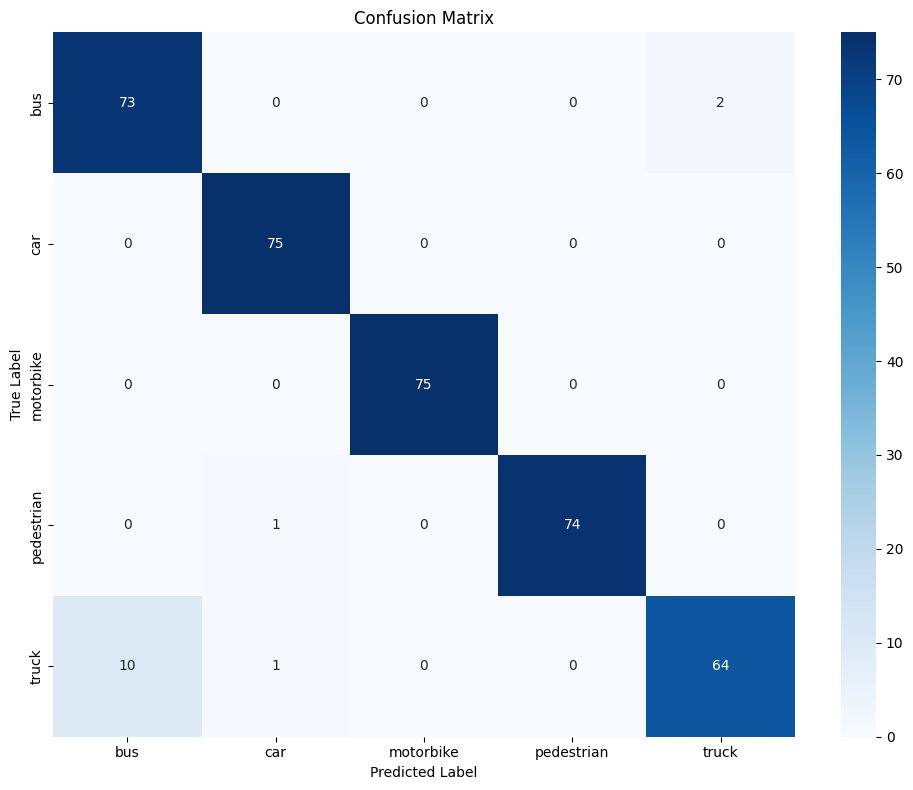

Đã lưu Confusion Matrix!


In [ ]:

# ===== BƯỚC 11: VẼ VÀ LƯU CONFUSION MATRIX =====
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'), dpi=300)
plt.show()
print("Đã lưu Confusion Matrix!")

# Lưu confusion matrix vào CSV
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(os.path.join(RESULTS_DIR, 'confusion_matrix.csv'))

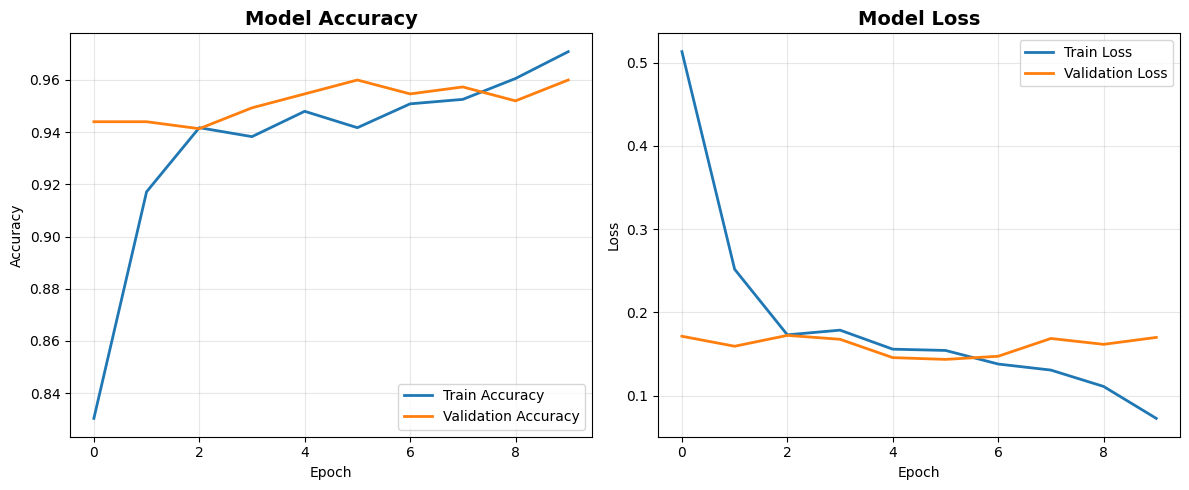

Đã lưu biểu đồ training/validation curves!


In [ ]:
# ===== BƯỚC 12: VẼ BIỂU ĐỒ TRAINING VÀ VALIDATION ACCURACY =====
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'training_validation_curves.png'), dpi=300)
plt.show()
print("Đã lưu biểu đồ training/validation curves!")


# PHân loại 1 ảnh


✓ Đã load model thành công!

Tìm thấy 5 ảnh trong folder '/content/drive/MyDrive/Testanh'
[1/5] Đang xử lý: anh1.jpg
   → Ô tô (100.0%)
[2/5] Đang xử lý: anh2.jpg
   → Xe buýt (100.0%)
[3/5] Đang xử lý: anh5.jpg
   → Người đi bộ (100.0%)
[4/5] Đang xử lý: anh4.jpg
   → Xe máy (100.0%)
[5/5] Đang xử lý: anh3.jpg
   → Xe tải (99.0%)


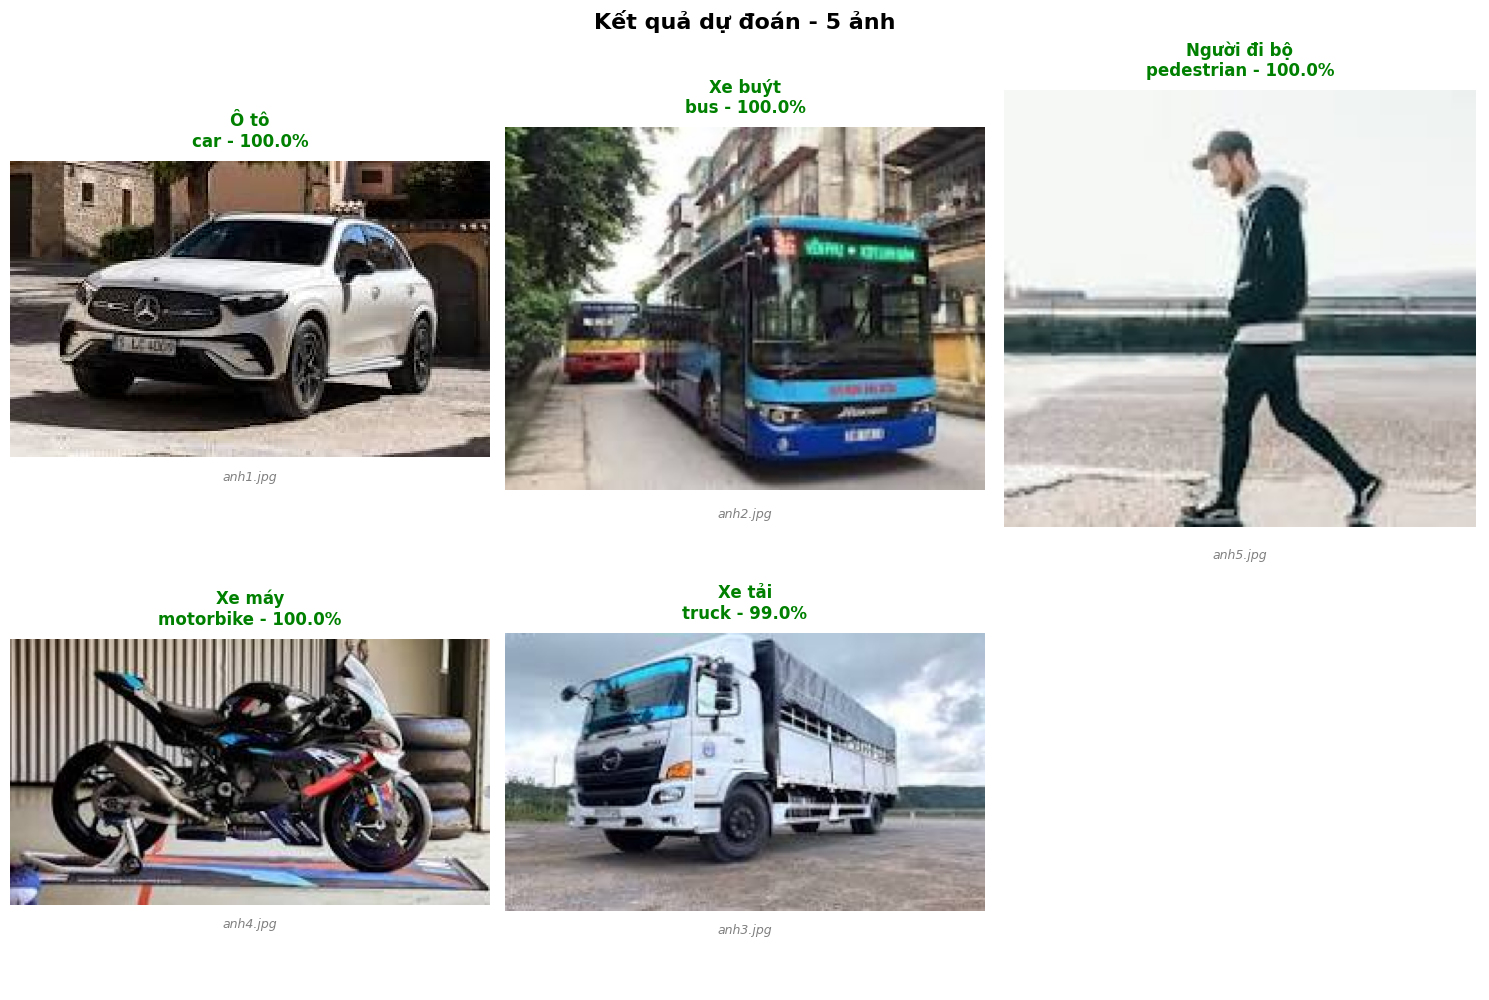


✓ Đã hiển thị 5 ảnh!

CHI TIẾT KẾT QUẢ DỰ ĐOÁN

[1] anh1.jpg
   Dự đoán: Ô tô (CAR)
   Độ tin cậy: 99.97%
   Phân bố xác suất:
      Xe buýt        :  0.01% 
      Ô tô           : 99.97% █████████████████████████████
      Xe máy         :  0.00% 
      Người đi bộ    :  0.00% 
      Xe tải         :  0.02% 

[2] anh2.jpg
   Dự đoán: Xe buýt (BUS)
   Độ tin cậy: 100.00%
   Phân bố xác suất:
      Xe buýt        : 100.00% █████████████████████████████
      Ô tô           :  0.00% 
      Xe máy         :  0.00% 
      Người đi bộ    :  0.00% 
      Xe tải         :  0.00% 

[3] anh5.jpg
   Dự đoán: Người đi bộ (PEDESTRIAN)
   Độ tin cậy: 100.00%
   Phân bố xác suất:
      Xe buýt        :  0.00% 
      Ô tô           :  0.00% 
      Xe máy         :  0.00% 
      Người đi bộ    : 100.00% ██████████████████████████████
      Xe tải         :  0.00% 

[4] anh4.jpg
   Dự đoán: Xe máy (MOTORBIKE)
   Độ tin cậy: 100.00%
   Phân bố xác suất:
      Xe buýt        :  0.00% 
      Ô tô        

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Load model
model = keras.models.load_model('/content/drive/MyDrive/labAI/final_model.h5')

print("✓ Đã load model thành công!")

# Tên các lớp
class_names = ['bus', 'car', 'motorbike', 'pedestrian', 'truck']
class_names_vn = {
    'bus': 'Xe buýt',
    'car': 'Ô tô',
    'motorbike': 'Xe máy',
    'pedestrian': 'Người đi bộ',
    'truck': 'Xe tải'
}

# ===== CẤU HÌNH =====
IMAGE_FOLDER = '/content/drive/MyDrive/Testanh'  # Thư mục chứa ảnh

# ===== HÀM DỰ ĐOÁN =====
def predict_image(img_path, model):
    """Dự đoán cho 1 ảnh"""
    img = Image.open(img_path)

    # Resize về kích thước model yêu cầu
    input_shape = model.input_shape[1:3]
    img_resized = img.resize((input_shape[1], input_shape[0]))

    # Preprocess
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Dự đoán
    predictions = model.predict(img_array, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    predicted_class = class_names[predicted_idx]
    predicted_class_vn = class_names_vn[predicted_class]
    confidence = predictions[0][predicted_idx]

    return img, predicted_class, predicted_class_vn, confidence, predictions[0]

# ===== LẤY DANH SÁCH ẢNH =====
image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.webp']
image_files = []

for ext in image_extensions:
    image_files.extend(Path(IMAGE_FOLDER).glob(f'*{ext}'))
    image_files.extend(Path(IMAGE_FOLDER).glob(f'*{ext.upper()}'))

print(f"\nTìm thấy {len(image_files)} ảnh trong folder '{IMAGE_FOLDER}'")
print("="*70)

# ===== DỰ ĐOÁN VÀ LƯU KẾT QUẢ =====
results = []

for idx, img_path in enumerate(image_files, 1):
    print(f"[{idx}/{len(image_files)}] Đang xử lý: {img_path.name}")

    try:
        img, predicted_class, predicted_class_vn, confidence, all_probs = predict_image(img_path, model)

        results.append({
            'img': img,
            'filename': img_path.name,
            'class': predicted_class,
            'class_vn': predicted_class_vn,
            'confidence': confidence,
            'probs': all_probs
        })

        print(f"   → {predicted_class_vn} ({confidence:.1%})")

    except Exception as e:
        print(f"   ✗ Lỗi: {e}")

print("="*70)

# ===== HIỂN THỊ TẤT CẢ ẢNH =====
num_images = len(results)
if num_images == 0:
    print("Không có ảnh nào để hiển thị!")
else:
    # Tính số hàng và cột cho grid
    cols = min(3, num_images)  # Tối đa 3 cột
    rows = (num_images + cols - 1) // cols  # Làm tròn lên

    # Tạo figure
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))

    # Đảm bảo axes luôn là array 2D
    if num_images == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)

    # Hiển thị từng ảnh
    for idx, result in enumerate(results):
        row = idx // cols
        col = idx % cols
        ax = axes[row, col]

        # Hiển thị ảnh
        ax.imshow(result['img'])

        # Tạo title với màu sắc theo độ tin cậy
        confidence = result['confidence']
        if confidence >= 0.9:
            color = 'green'
        elif confidence >= 0.7:
            color = 'orange'
        else:
            color = 'red'

        title = f"{result['class_vn']}\n{result['class']} - {confidence:.1%}"
        ax.set_title(title, fontsize=12, fontweight='bold', color=color, pad=10)
        ax.axis('off')

        # Thêm tên file ở dưới
        ax.text(0.5, -0.05, result['filename'],
                ha='center', va='top', transform=ax.transAxes,
                fontsize=9, style='italic', color='gray')

    # Ẩn các subplot trống (nếu có)
    for idx in range(num_images, rows * cols):
        row = idx // cols
        col = idx % cols
        axes[row, col].axis('off')

    plt.suptitle(f'Kết quả dự đoán - {num_images} ảnh',
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

    print(f"\n✓ Đã hiển thị {num_images} ảnh!")

# ===== HIỂN THỊ CHI TIẾT XÁC SUẤT =====
print("\n" + "="*70)
print("CHI TIẾT KẾT QUẢ DỰ ĐOÁN")
print("="*70)

for idx, result in enumerate(results, 1):
    print(f"\n[{idx}] {result['filename']}")
    print(f"   Dự đoán: {result['class_vn']} ({result['class'].upper()})")
    print(f"   Độ tin cậy: {result['confidence']:.2%}")
    print(f"   Phân bố xác suất:")

    for i, class_name in enumerate(class_names):
        prob = result['probs'][i]
        bar = '█' * int(prob * 30)
        print(f"      {class_names_vn[class_name]:15s}: {prob*100:5.2f}% {bar}")

print("\n" + "="*70)
print("✓ HOÀN THÀNH!")
print("="*70)
